In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_excel(r"C:\Users\HP\Downloads\Decision Tree\Decision Tree\heart_disease.xlsx",sheet_name='Heart_disease')
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
dups=data.duplicated()
print(dups.sum())

1


In [5]:
data.drop_duplicates(inplace=True)
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


In [6]:
data['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

In [7]:
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [8]:
#median1=data['oldpeak'].median()
data['oldpeak'] = data['oldpeak'].fillna(data['oldpeak'].median())

In [9]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [10]:
#import seaborn as sns
#m=len(data.columns)
#for j in range(0,m):
    #plt.figure(figsize=(6, 4))
    #sns.histplot(data=data[data.columns[j]],bins=20)
    #plt.show()

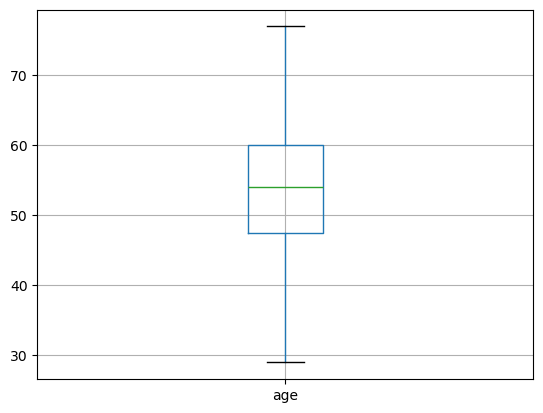

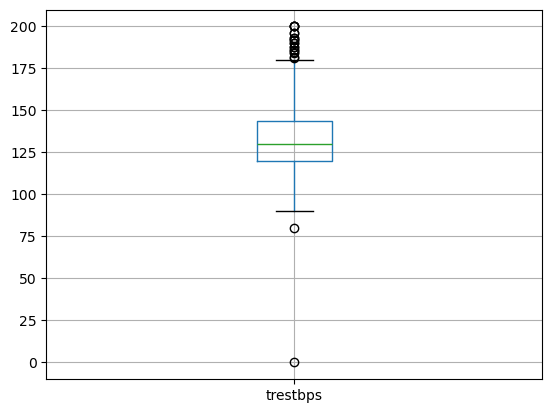

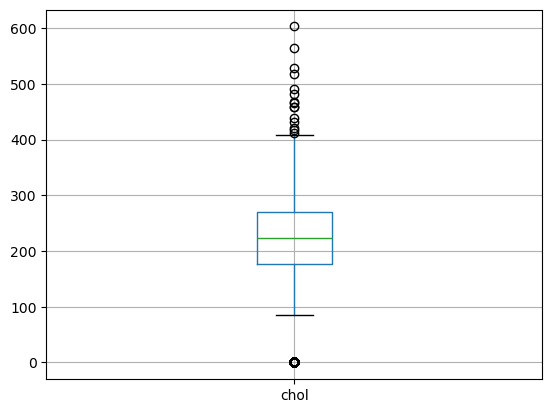

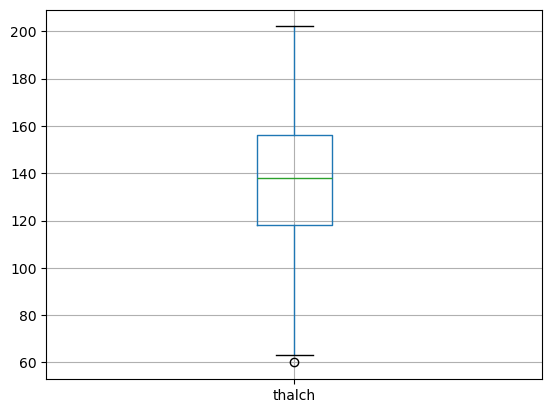

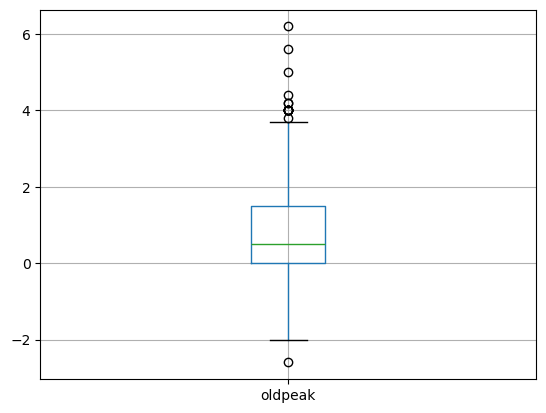

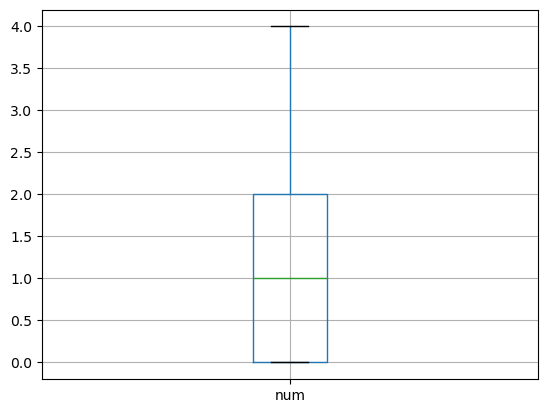

In [11]:
data_numeric=data.select_dtypes(include=['int64','float64'])
n=len(data_numeric.columns)
for i in range(0,n):
    data_numeric.boxplot(column=[data_numeric.columns[i]])
    plt.show()

In [12]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=col.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_range=Q1-(1.5*IQR)
    upper_range=Q3+(1.5*IQR)
    return lower_range,upper_range

In [13]:
lrtrestbps,urtrestbps=remove_outlier(data['trestbps'])
data['trestbps']=np.where(data['trestbps']>urtrestbps,urtrestbps,data['trestbps'])
data['trestbps']=np.where(data['trestbps']<lrtrestbps,lrtrestbps,data['trestbps'])

lrchol,urchol=remove_outlier(data['chol'])
data['chol']=np.where(data['chol']>urchol,urchol,data['chol'])
data['chol']=np.where(data['chol']<lrchol,lrchol,data['chol'])

lroldpeak,uroldpeak=remove_outlier(data['oldpeak'])
data['oldpeak']=np.where(data['oldpeak']>uroldpeak,uroldpeak,data['oldpeak'])
data['oldpeak']=np.where(data['oldpeak']<lroldpeak,lroldpeak,data['oldpeak'])


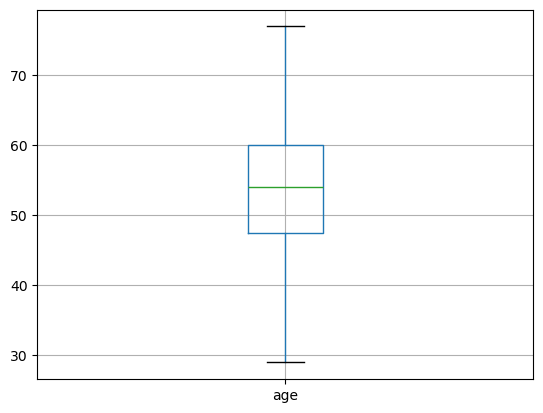

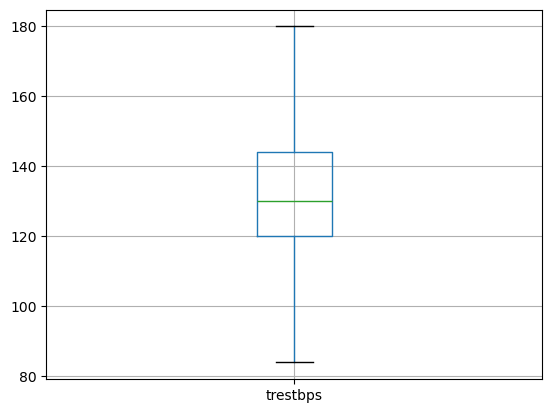

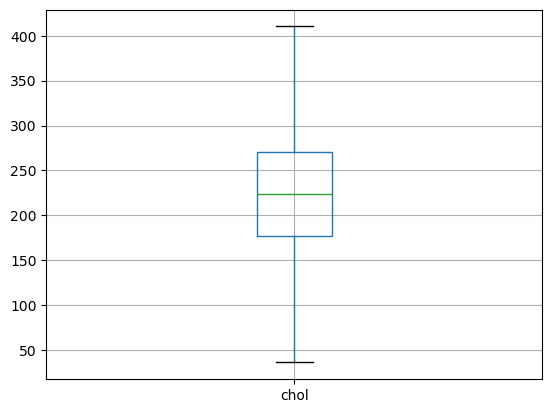

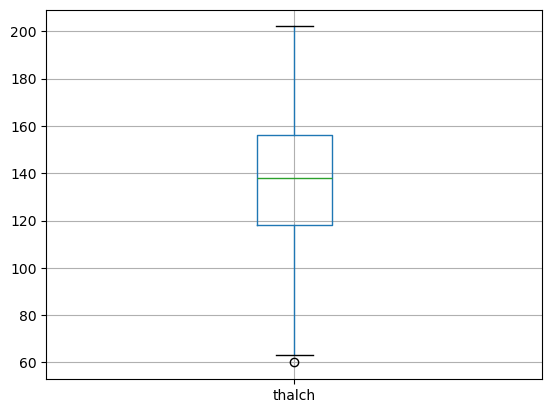

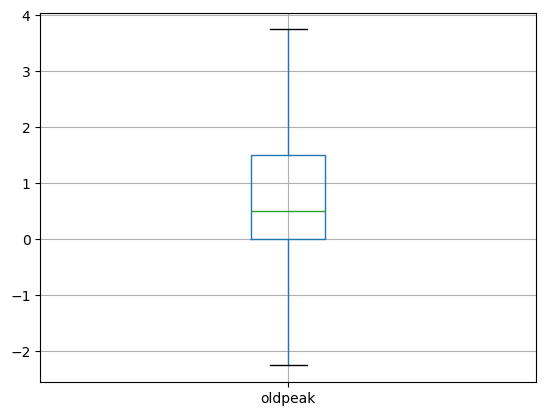

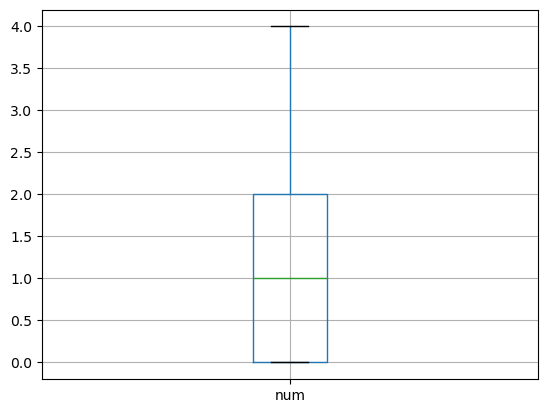

In [14]:
data_numeric=data.select_dtypes(include=['int64','float64'])
n=len(data_numeric.columns)
for i in range(0,n):
    data_numeric.boxplot(column=[data_numeric.columns[i]])
    plt.show()

In [15]:
data_encoded=pd.get_dummies(data,columns=['cp','restecg','slope','thal','sex'],dtype='int')
data_encoded

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_asymptomatic,cp_atypical angina,...,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,sex_Female,sex_Male
0,63,145.0,233.00,True,150,False,2.3,0,0,0,...,0,0,1,0,0,1,0,0,0,1
1,41,135.0,203.00,False,132,False,0.0,0,0,1,...,1,0,0,1,0,1,0,0,0,1
2,57,140.0,192.00,False,148,False,0.4,0,1,0,...,1,0,0,1,0,1,0,0,0,1
3,52,118.0,186.00,False,190,False,0.0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
4,57,110.0,201.00,False,126,True,1.5,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,125.0,36.25,False,120,False,1.5,4,1,0,...,1,0,0,0,1,0,0,1,0,1
904,62,166.0,170.00,False,120,True,3.0,4,1,0,...,0,1,0,1,0,0,0,1,0,1
905,56,170.0,36.25,False,123,True,2.5,4,0,0,...,0,0,1,0,0,0,1,0,0,1
906,56,144.0,208.00,True,105,TURE,0.5,4,0,0,...,0,1,1,0,0,1,0,0,0,1


In [16]:
data_encoded.replace({'TRUE':1, True:1, 'TURE':1, 'FALSE':0, False:0},inplace=True)
data_encoded

C:\Users\HP\AppData\Local\Temp\ipykernel_33540\330049157.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_encoded.replace({'TRUE':1, True:1, 'TURE':1, 'FALSE':0, False:0},inplace=True)


,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_asymptomatic,cp_atypical angina,...,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,sex_Female,sex_Male
0,63,145.0,233.00,1,150,0,2.3,0,0,0,...,0,0,1,0,0,1,0,0,0,1
1,41,135.0,203.00,0,132,0,0.0,0,0,1,...,1,0,0,1,0,1,0,0,0,1
2,57,140.0,192.00,0,148,0,0.4,0,1,0,...,1,0,0,1,0,1,0,0,0,1
3,52,118.0,186.00,0,190,0,0.0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
4,57,110.0,201.00,0,126,1,1.5,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,125.0,36.25,0,120,0,1.5,4,1,0,...,1,0,0,0,1,0,0,1,0,1
904,62,166.0,170.00,0,120,1,3.0,4,1,0,...,0,1,0,1,0,0,0,1,0,1
905,56,170.0,36.25,0,123,1,2.5,4,0,0,...,0,0,1,0,0,0,1,0,0,1
906,56,144.0,208.00,1,105,1,0.5,4,0,0,...,0,1,1,0,0,1,0,0,0,1


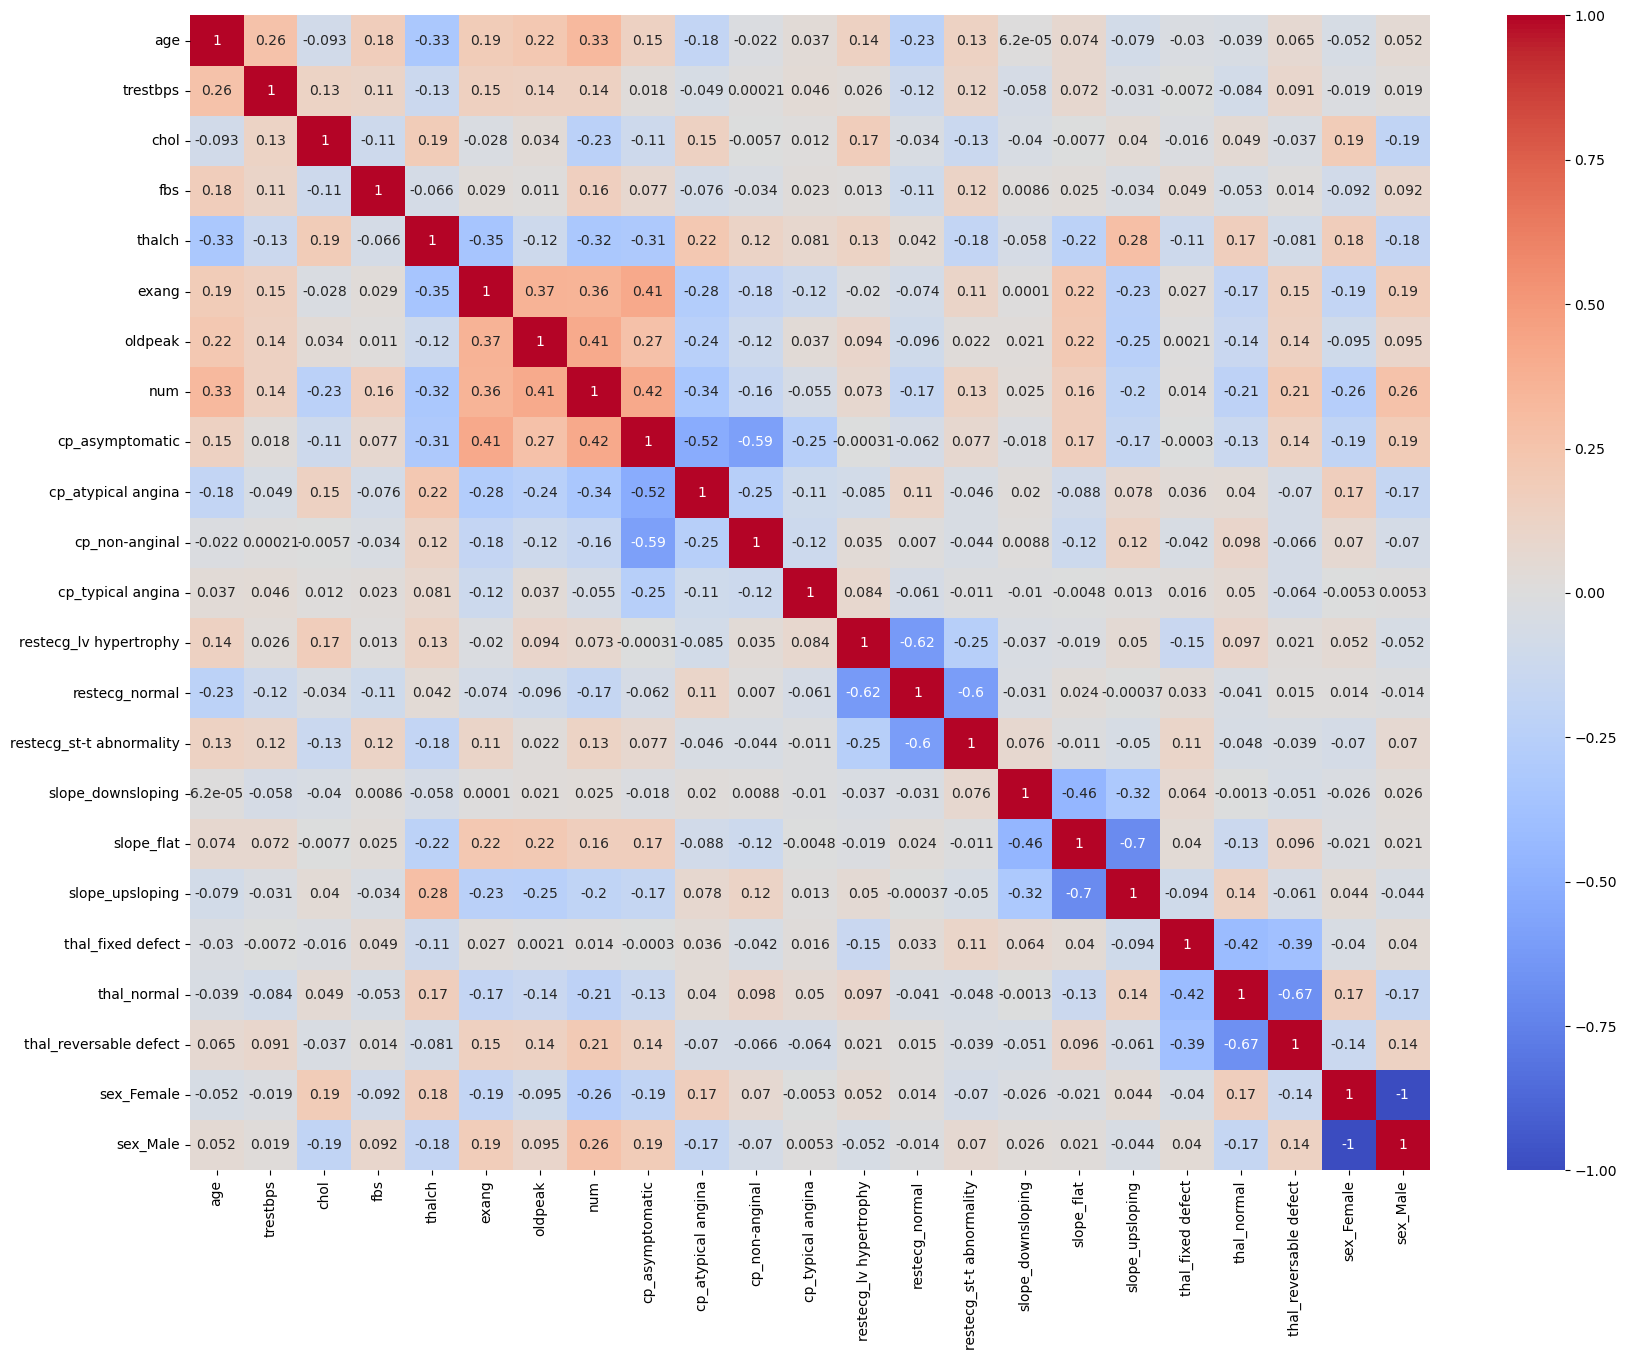

In [17]:
import seaborn as sns
plt.figure(figsize=(20,15))
sns.heatmap(data_encoded.corr(),annot=True,cmap='coolwarm')
plt.show()

In [18]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split

x=data_encoded.drop(['num','sex_Male','thal_fixed defect','slope_downsloping','restecg_st-t abnormality','cp_atypical angina','age'],axis=1)
y=data_encoded[['num']]


In [19]:
from sklearn.preprocessing import StandardScaler 

In [20]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
print(x_scaled)

x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)
print(x_scaled_df)

x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)
print(x_train)

[[ 0.60828902  0.26538639  1.97552593 ... -0.85880609 -0.78533801
  -0.51477473]
 [ 0.0899518  -0.04358997 -0.50619432 ... -0.85880609 -0.78533801
  -0.51477473]
 [ 0.34912041 -0.1568813  -0.50619432 ... -0.85880609 -0.78533801
  -0.51477473]
 ...
 [ 1.90413208 -1.76098356 -0.50619432 ...  1.16440721 -0.78533801
  -0.51477473]
 [ 0.5564553   0.00790609  1.97552593 ... -0.85880609 -0.78533801
  -0.51477473]
 [ 0.45278785  0.71855172  1.97552593 ... -0.85880609  1.27333707
  -0.51477473]]
     trestbps      chol       fbs    thalch     exang   oldpeak  \
0    0.608289  0.265386  1.975526  0.523285 -0.833863  1.409890   
1    0.089952 -0.043590 -0.506194 -0.148399 -0.833863 -0.835450   
2    0.349120 -0.156881 -0.506194  0.448654 -0.833863 -0.444956   
3   -0.791221 -0.218677 -0.506194  2.015918 -0.833863 -0.835450   
4   -1.205891 -0.064188 -0.506194 -0.372294  1.199238  0.628902   
..        ...       ...       ...       ...       ...       ...   
902 -0.428385 -1.760984 -0.506194 -0.59

In [21]:
print(x_test)

     trestbps    chol  fbs  thalch  exang  oldpeak  cp_asymptomatic  \
869     137.0  142.00    0      68      0      0.5                0   
439     170.0   36.25    1     105      1      0.0                1   
342     120.0  291.00    0     160      0      0.0                0   
735     132.0  218.00    0     140      1      1.5                1   
785     110.0  206.00    0     108      1      0.0                1   
..        ...     ...  ...     ...    ...      ...              ...   
598     110.0  265.00    0     150      1      1.0                1   
868     126.0  312.00    0     156      0      0.5                1   
445     140.0  203.00    1     155      1      3.1                1   
786     122.0  286.00    0     116      1      3.2                1   
25      112.0  160.00    0     138      0      0.0                0   

     cp_non-anginal  cp_typical angina  restecg_lv hypertrophy  \
869               1                  0                       0   
439            

In [22]:
print(y_train)

     num
84     0
10     0
616    1
250    0
478    1
..   ...
106    0
270    0
861    3
435    1
102    0

[725 rows x 1 columns]


In [23]:
print(y_test)

     num
869    3
439    1
342    0
735    2
785    3
..   ...
598    1
868    3
445    1
786    3
25     0

[182 rows x 1 columns]


In [24]:
model_DecisionTree=DecisionTreeClassifier(criterion="gini", random_state=10)

# fit the model on the data & predict the values
model_DecisionTree.fit(x_train,y_train)

DecisionTreeClassifier(random_state=10)

In [25]:
model_DecisionTree.get_depth()

17

In [26]:
y_pred = model_DecisionTree.predict(x_test)
print(y_pred)

[1 3 0 1 3 2 0 0 1 3 0 2 0 0 0 1 0 0 2 1 1 0 1 3 0 1 0 3 0 0 0 1 0 1 0 3 3
 1 0 3 0 0 1 1 0 0 0 0 0 3 1 1 1 3 0 0 2 1 3 2 3 0 3 0 1 2 1 2 2 1 0 0 1 1
 0 0 3 0 1 0 3 0 0 2 0 0 0 2 0 3 3 4 0 0 1 1 1 0 1 0 0 1 2 1 0 2 3 1 2 0 0
 0 3 2 0 3 1 1 0 0 2 0 0 1 1 0 0 0 2 1 1 0 1 2 3 0 3 0 2 0 1 0 0 1 2 0 1 0
 3 1 1 0 0 0 2 1 3 0 1 0 1 0 0 1 0 1 0 3 3 0 3 3 0 1 0 0 0 1 1 2 0 0]


In [27]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
# confusion matrix
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[63 16  5  5  0]
 [12 20  6  9  0]
 [ 2  5  5  7  1]
 [ 3  6  2  6  0]
 [ 2  3  3  1  0]]
0.5164835164835165
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        89
           1       0.40      0.43      0.41        47
           2       0.24      0.25      0.24        20
           3       0.21      0.35      0.27        17
           4       0.00      0.00      0.00         9

    accuracy                           0.52       182
   macro avg       0.32      0.35      0.33       182
weighted avg       0.53      0.52      0.52       182



In [28]:
#model_DecisionTree=DecisionTreeClassifier(criterion="gini", max_depth=5, min_samples_leaf=10, random_state=10, class_weight='balanced')
from random import randint
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.tree import DecisionTreeRegressor


param_dist = {
    'max_depth': [randint(1, 20)],
    'min_samples_split': [randint(2, 20)],
    'min_samples_leaf': [randint(1, 20)]
}
dtree_reg = DecisionTreeRegressor(random_state=42) 
random_search = RandomizedSearchCV(dtree_reg, param_distributions=param_dist, 
                                   n_iter=100, cv=5, random_state=42)
random_search.fit(x_train, y_train)
best_params_random = random_search.best_params_
best_score_random = random_search.best_score_

print(f"Best Parameters (Random Search): {best_params_random}")
print(f"Best Score (Random Search): {best_score_random}")
# fit the model on the data & predict the values
model_DecisionTree.fit(x_train,y_train)

Best Parameters (Random Search): {'min_samples_split': 6, 'min_samples_leaf': 17, 'max_depth': 5}
Best Score (Random Search): 0.30221212759928334


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=100. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


DecisionTreeClassifier(random_state=10)

In [29]:
from sklearn.metrics import mean_squared_error

param_grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dtree_reg = DecisionTreeRegressor(random_state=42) # Initialize a decision tree regressor
grid_search = GridSearchCV(estimator=dtree_reg, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)
best_dtree_reg = grid_search.best_estimator_ # Get the best estimator from the grid search
y_pred = best_dtree_reg.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")
print(f"Test RMSE: {rmse}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Test RMSE: 1.1006820706212017


In [30]:
model_DecisionTree=DecisionTreeClassifier(criterion="gini", max_depth=10, min_samples_leaf=4, min_samples_split=10, class_weight='balanced')
model_DecisionTree.fit(x_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=4, min_samples_split=10)

In [31]:
model_DecisionTree.get_depth()

10

In [32]:
y_pred = model_DecisionTree.predict(x_test)
print(y_pred)

[0 3 0 3 0 3 1 0 2 3 2 1 0 0 2 3 0 0 2 3 0 0 3 3 1 3 0 3 3 0 2 1 0 0 0 2 3
 0 0 3 0 0 0 0 3 0 0 0 0 3 1 2 1 1 0 0 3 0 1 4 2 0 3 0 0 1 3 0 3 3 0 1 1 2
 0 1 3 0 2 0 0 0 1 0 0 0 0 2 0 3 3 4 0 0 1 1 4 0 1 0 0 1 1 4 0 2 1 1 1 1 1
 3 1 1 0 3 1 1 2 0 1 0 0 0 3 0 0 4 1 1 0 0 3 3 3 0 1 0 3 0 3 0 0 2 2 0 0 0
 3 0 3 0 0 3 1 1 3 0 1 0 3 1 0 0 0 0 1 4 0 0 4 3 0 0 0 2 4 1 1 2 4 0]


In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
# confusion matrix
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[66 12  3  7  1]
 [ 9 18  5 14  1]
 [ 2  4  4  8  2]
 [ 3  3  2  5  4]
 [ 1  1  3  3  1]]
0.5164835164835165
              precision    recall  f1-score   support

           0       0.81      0.74      0.78        89
           1       0.47      0.38      0.42        47
           2       0.24      0.20      0.22        20
           3       0.14      0.29      0.19        17
           4       0.11      0.11      0.11         9

    accuracy                           0.52       182
   macro avg       0.35      0.35      0.34       182
weighted avg       0.56      0.52      0.54       182



In [34]:
print(list(zip(data_encoded.columns, model_DecisionTree.feature_importances_)))

[('age', np.float64(0.15289863072124957)), ('trestbps', np.float64(0.21110792327082095)), ('chol', np.float64(0.03774236383357219)), ('fbs', np.float64(0.19047287491895026)), ('thalch', np.float64(0.021028423925199168)), ('exang', np.float64(0.20607606258025277)), ('oldpeak', np.float64(0.08958156934868824)), ('num', np.float64(0.0025366562731083723)), ('cp_asymptomatic', np.float64(0.00578645986805073)), ('cp_atypical angina', np.float64(0.014025393590210405)), ('cp_non-anginal', np.float64(0.02267447474891822)), ('cp_typical angina', np.float64(0.012884460892642119)), ('restecg_lv hypertrophy', np.float64(0.02631321067275029)), ('restecg_normal', np.float64(0.006871495355586717)), ('restecg_st-t abnormality', np.float64(0.0)), ('slope_downsloping', np.float64(0.0))]


In [35]:
from sklearn import tree
with open("model_DecisionTree.txt","w") as f:
    
    f = tree.export_graphviz(model_DecisionTree, feature_names=x.columns,
                            out_file=f)
    
# generate the file and upload the code in webgraphviz.com to plot the decision tree

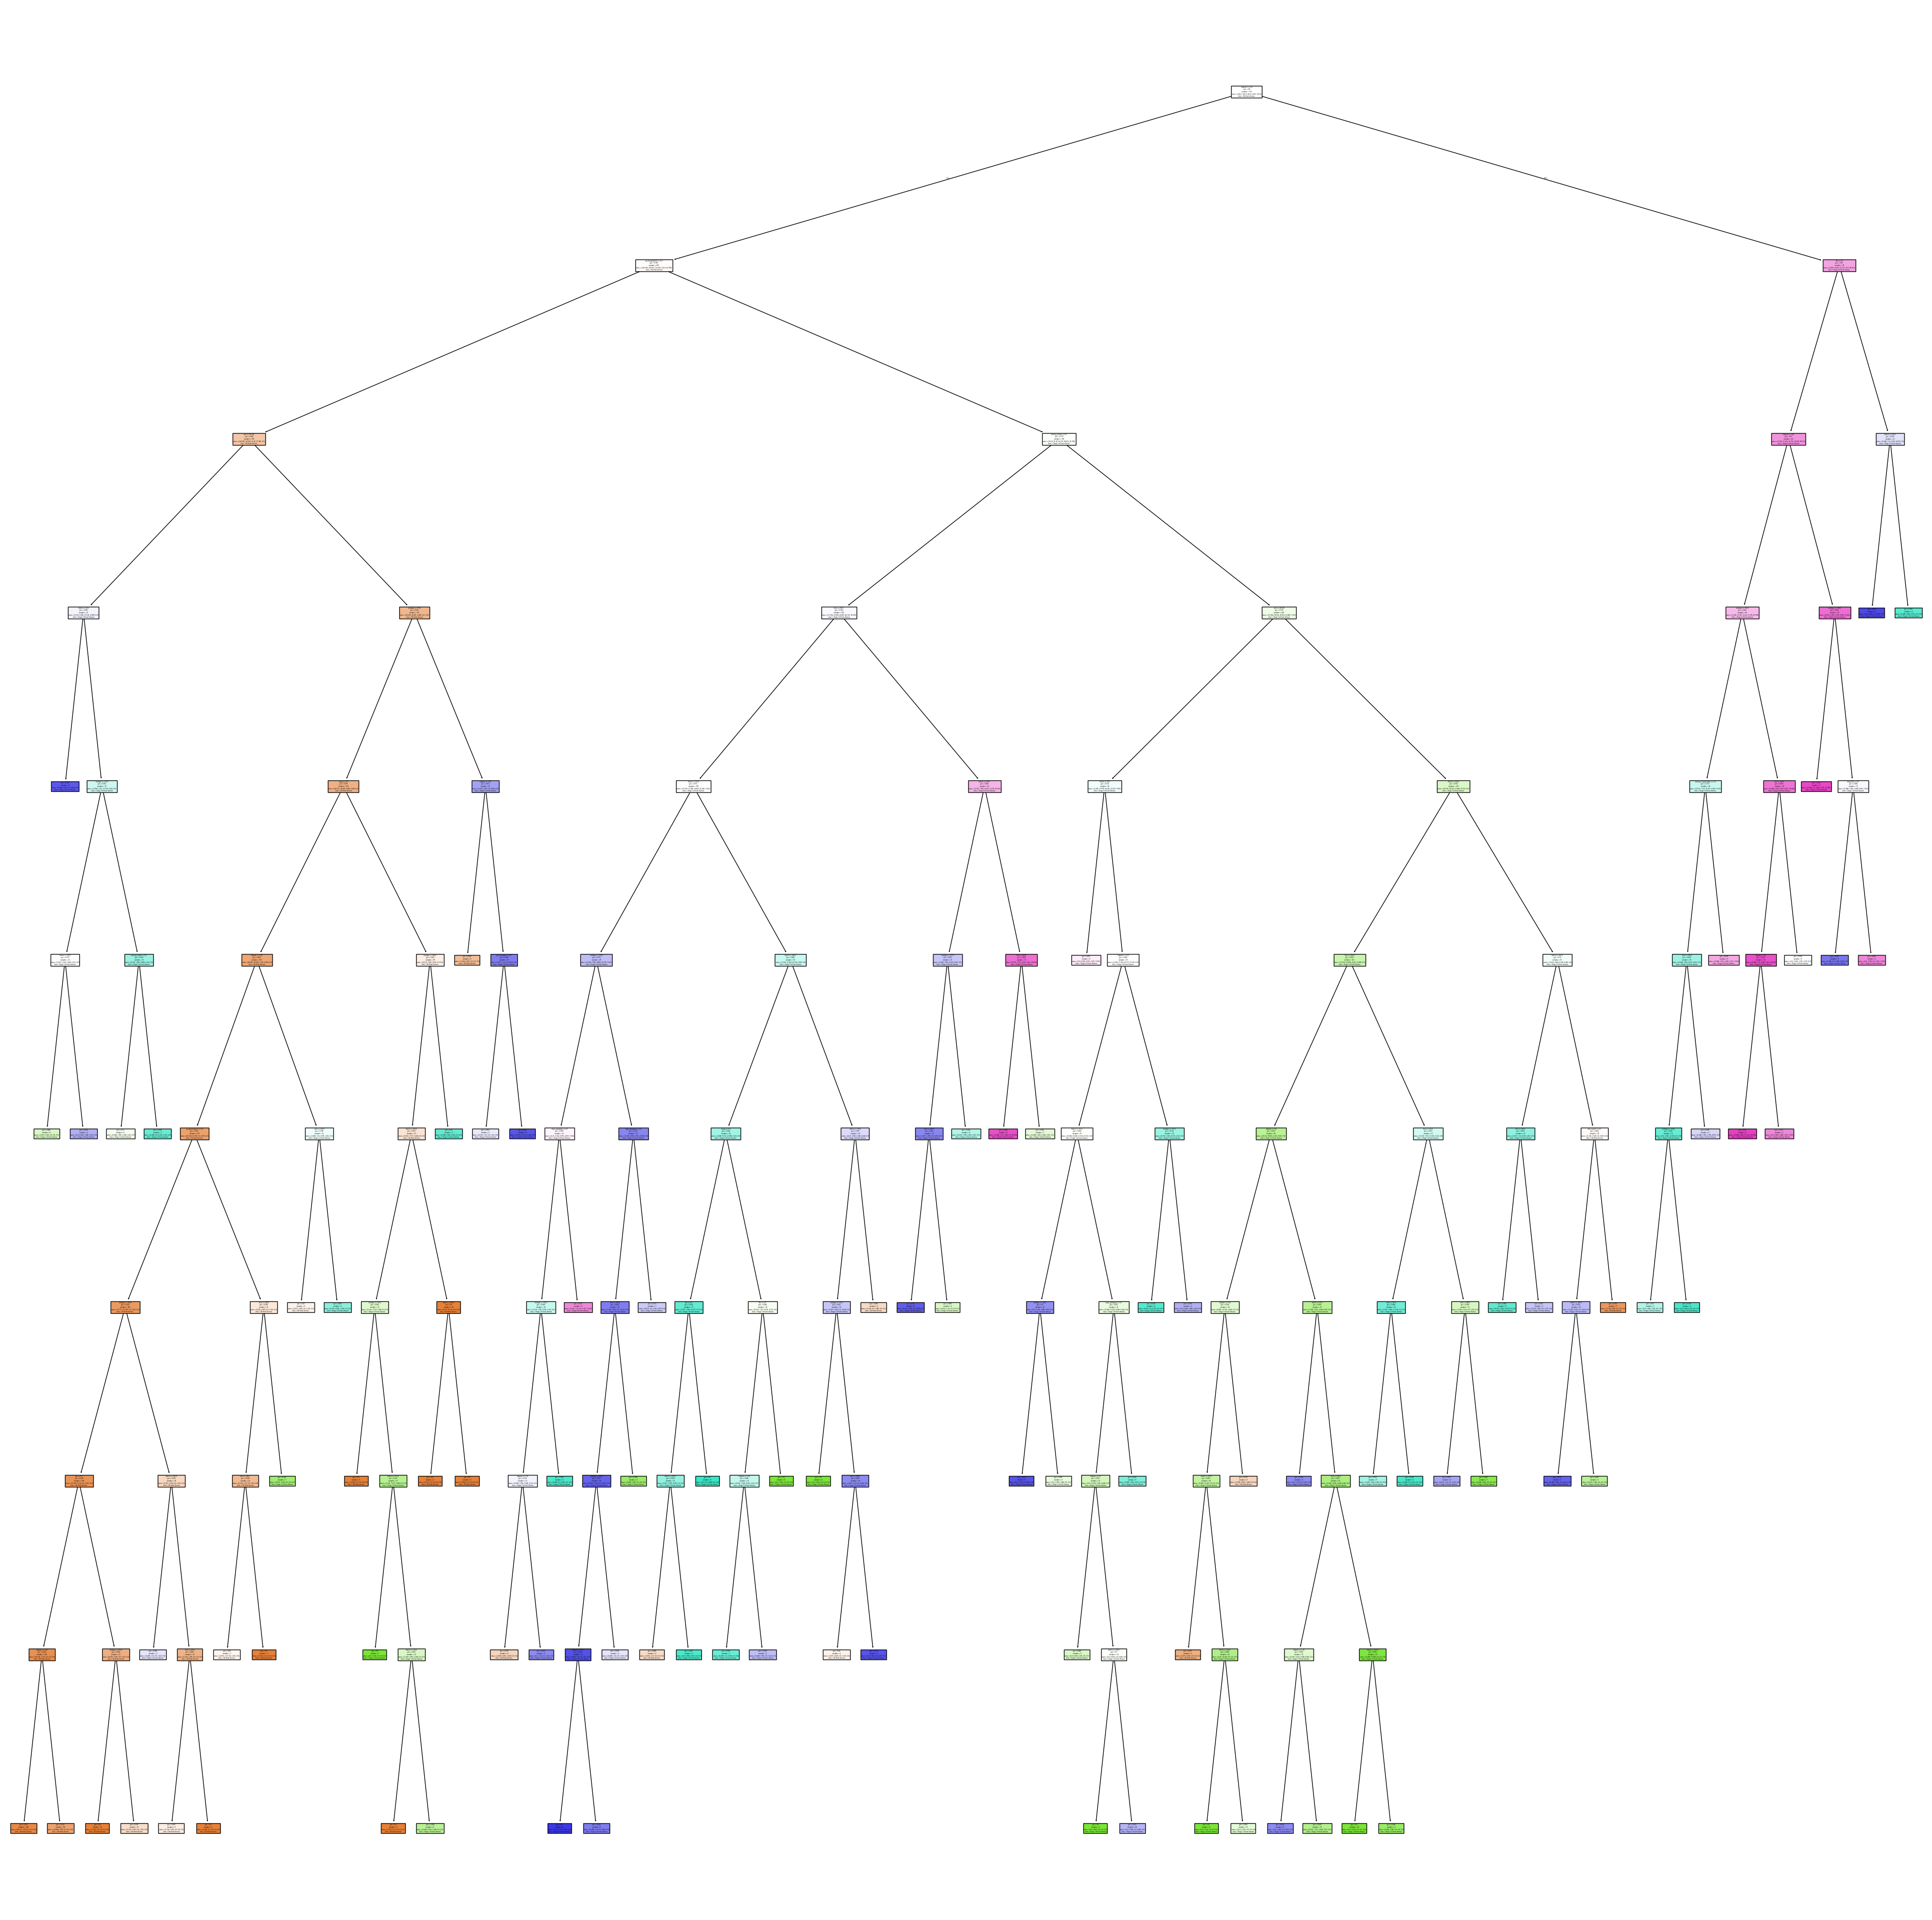

In [36]:
colname = x.columns

plt.figure(figsize=(50,50))  # enlarge the figure
tree.plot_tree(model_DecisionTree, 
               filled=True,              # fill colors for better readability
               feature_names=list(colname),  # show column names
               class_names=['No Heart disease','Stage 1 of heart disease','Stage 2 of heart disease','Stage 3 of heart disease','Stage 4 of heart disease'])  # target class labels
plt.show()